In [1]:
%load_ext autoreload
%autoreload 2

# allows to import modules from root directory
import sys
import os
sys.path.append(os.path.abspath('..'))

In [2]:
import GridWorld
import matplotlib.pyplot as plt
from renderer import GridWorldRenderer
import scipy.stats as stats
import numpy as np
from scipy.optimize import brentq

In [20]:
env = GridWorld.GridWorld(grid_size=8, glucose_target=50, glucose_max=100,
                 n_food=20, max_steps=200, metabolism_rate=1, intake_amount=10, 
                 drive_n=2, drive_m=1, seed=6)

In [84]:
# video rendering
renderer = GridWorldRenderer(env)
renderer.record_episode(out_path="episode.mp4", fps=1)

KeyboardInterrupt: 

In [21]:
all_glucose = [env._get_obs()["glucose_level"]]
all_reward = [null_reward := 0]  # Initialize with a placeholder for the first step
all_drive = [env._get_obs()["drive"]]
for t in range(100):
    step = env.step()
    all_glucose.append(step[0]["glucose_level"])
    all_drive.append(step[0]["drive"])
    all_reward.append(step[1])

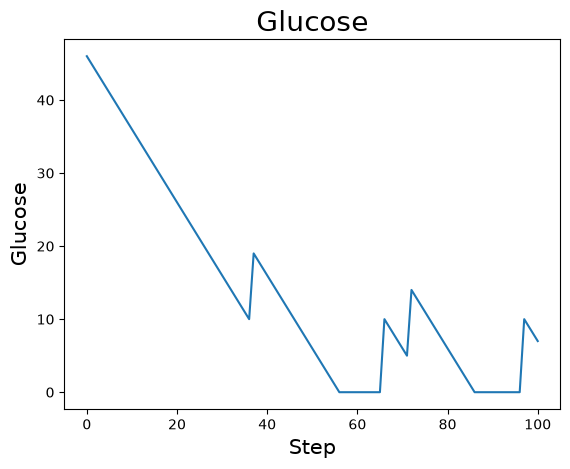

In [7]:
plt.plot(all_glucose)
plt.xlabel("Step", fontsize=15)
plt.ylabel("Glucose", fontsize=15)
plt.title("Glucose", fontsize=20)
#plt.savefig("../plots/glucose-m3-i10.png", dpi=300, bbox_inches='tight')
plt.show()

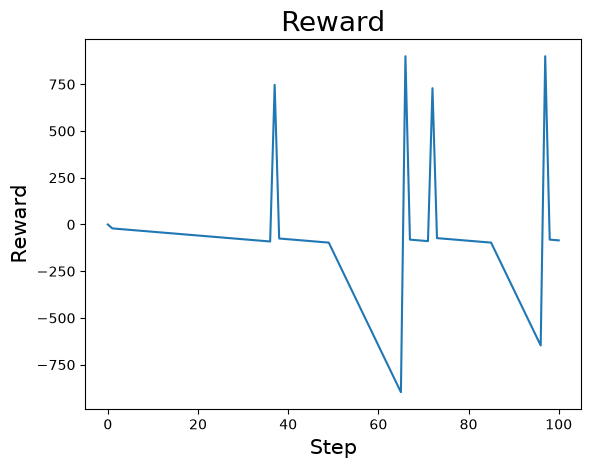

In [71]:
plt.plot(all_reward)
plt.xlabel("Step", fontsize=15)
plt.ylabel("Reward", fontsize=15)
plt.title("Reward", fontsize=20)
#plt.savefig("../plots/reward_drive_n1.png", dpi=300, bbox_inches='tight')
plt.show()

In [66]:
print(all_reward)
print(all_glucose)

[0, -9.0, -11.0, -13.0, -15.0, -17.0, -19.0, -21.0, -23.0, -25.0, -27.0, -29.0, -31.0, -33.0, 225.0, -17.0, -19.0, -21.0, -23.0, -25.0, -27.0, -29.0, -31.0, -33.0, -35.0, -37.0, -39.0, -41.0, -43.0, -45.0, -47.0, -49.0, -51.0, -53.0, -55.0, -57.0, 441.0, -41.0, -43.0, -45.0, -47.0, -49.0, -51.0, -53.0, -55.0, -57.0, -59.0, -61.0, -63.0, -65.0, -67.0, -69.0, -71.0, -73.0, -75.0, -77.0, -79.0, -81.0, -83.0, -85.0, -87.0, -89.0, -91.0, -93.0, -95.0, 783.0, -79.0, -81.0, -83.0, -85.0, -87.0, 711.0, -71.0, -73.0, -75.0, -77.0, -79.0, -81.0, -83.0, -85.0, -87.0, -89.0, -91.0, -93.0, -95.0, -97.0, -147.0, -197.0, -247.0, -297.0, -347.0, -397.0, -447.0, -497.0, -547.0, -597.0, 900.0, -81.0, -83.0, -85.0, -87.0]
[46, 45, 44, 43, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 42, 41, 40, 39, 38, 37, 36, 35, 34, 33, 32, 31, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 30, 29, 28, 27, 26, 25, 24, 23, 22, 21, 20, 19, 18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 11, 10, 9, 8, 7, 6, 15, 14, 13, 12

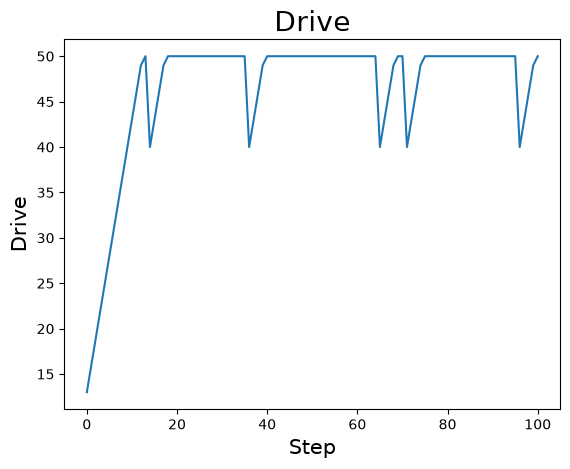

In [49]:
plt.plot(all_drive)
plt.xlabel("Step", fontsize=15)
plt.ylabel("Drive", fontsize=15)
plt.title("Drive", fontsize=20)
plt.savefig("../plots/drive_drive_n1.png", dpi=300, bbox_inches='tight')
plt.show()

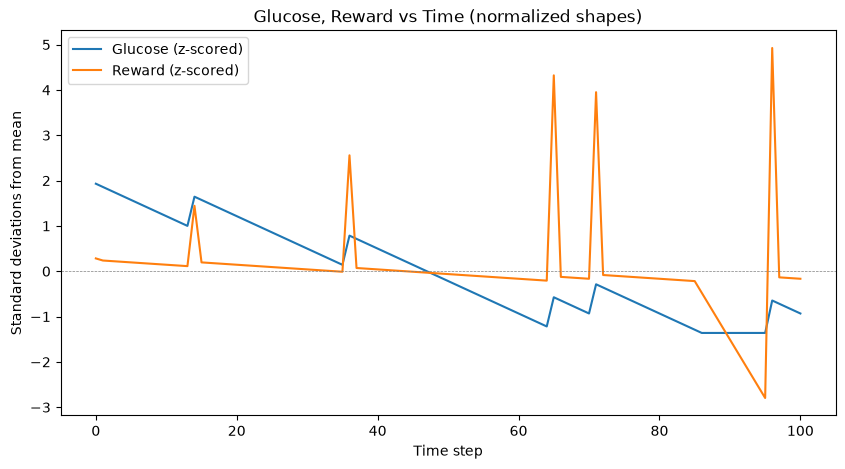

In [22]:
glucose_z = stats.zscore(all_glucose)
reward_z = stats.zscore(all_reward)

plt.figure(figsize=(10, 5))
plt.plot(glucose_z, label='Glucose (z-scored)')
plt.plot(reward_z, label='Reward (z-scored)')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Standard deviations from mean')
plt.title('Glucose, Reward vs Time (normalized shapes)')
plt.legend()
plt.savefig("../plots/glucose-reward-m1.png", dpi=300, bbox_inches='tight')
plt.show()